In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.research_config import ResearchConfig
from src.research_data import prepare_prices


# 01 Stock Data

Start here. Choose the research settings. Later modules load the saved settings and intermediate files from data/processed/current/. The default files are the repository’s existing inputs; their historical universe bias remains explicitly recorded.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


## 2. Settings

All model settings are chosen here. Each execution overwrites the current settings and input copies. After changing settings or inputs, rerun this notebook and the following modules in order.


In [2]:
CONFIG = ResearchConfig().validate()
cfg = CONFIG
PRICE_FILE = "data/inputs/prices.parquet"
MEMBERSHIP_FILE = None
ALLOW_LEGACY_UNIVERSE = True
display(pd.Series(cfg.to_dict(), name="Research settings"))


Files saved to /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current


train_fraction                      0.7
max_missing_fraction               0.05
correlation_neighbors                10
cointegration_alpha                0.01
integration_alpha                  0.05
top_n                                40
initial_capital                100000.0
entry_z                             1.5
target_probability                  0.7
memory_window                        60
structural_horizon                  252
max_horizon_days                    126
n_paths                            5000
seed                                 42
ewma_lambda                        0.94
max_open_pairs                     None
premium_budget_fraction            0.05
max_hedge_error                     0.1
slippage_bps                       10.0
commission_per_contract            0.65
n_placebos                          100
bootstrap_replications            10000
bootstrap_blocks           (10, 20, 40)
hac_lags                              5
Name: Research settings, dtype: object

## 3. Load and split prices

The first 70% of sessions form the training sample. Missingness is evaluated only there; test-period prices are never used to select assets. No live download occurs.


In [3]:
prices = pd.read_parquet(PRICE_FILE)
membership = pd.read_csv(MEMBERSHIP_FILE) if MEMBERSHIP_FILE is not None else None
train_prices, test_prices, availability = prepare_prices(
    prices, cfg, membership, ALLOW_LEGACY_UNIVERSE
)
display(
    pd.DataFrame(
        {
            "observations": [len(train_prices), len(test_prices)],
            "start": [train_prices.index.min(), test_prices.index.min()],
            "end": [train_prices.index.max(), test_prices.index.max()],
        },
        index=["Formation", "Out of sample"],
    )
)
display(availability.head(10))


,observations,start,end
Formation,1759,2016-01-04,2022-12-27
Out of sample,755,2022-12-28,2025-12-31


,ticker,formation_missing_fraction,retained
0,A,0.0,True
1,AAPL,0.0,True
2,ABBV,0.0,True
3,ABT,0.0,True
4,ACGL,0.0,True
5,ACN,0.0,True
6,ADBE,0.0,True
7,ADI,0.0,True
8,ADM,0.0,True
9,ADP,0.0,True


## 4. Inspect and save

These new files go into this run’s folder. Old thesis output files are preserved.


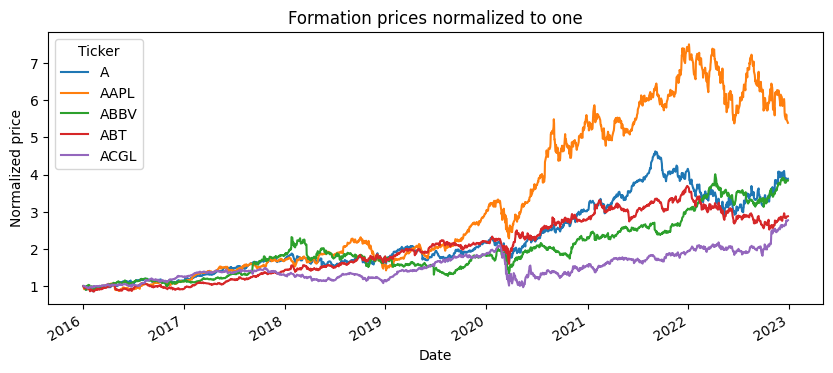

In [4]:
train_prices.to_parquet("train_prices.parquet")
test_prices.to_parquet("test_prices.parquet")
availability.to_parquet("availability.parquet")
ax = (train_prices.iloc[:, :5] / train_prices.iloc[0, :5]).plot(
    figsize=(10, 4), title="Formation prices normalized to one"
)
ax.set_ylabel("Normalized price")
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.
